In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [5]:
name_path = 'New_York_Air_Quality.csv'
folder_path = 'dataset'

file_path = os.path.join(folder_path, name_path)

df = pd.read_csv(file_path) 
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
df.head(5)


,Date,City,CO,NO2,SO2,O3,PM2.5,PM10,AQI
0,2025-01-01 00:00:00+00:00,New York,304.0,49.6,8.2,17.0,10.0,11.8,26.375000
1,2025-01-01 01:00:00+00:00,New York,289.0,43.3,7.1,26.0,8.8,10.4,26.183334
2,2025-01-01 02:00:00+00:00,New York,269.0,34.5,5.6,38.0,7.4,8.8,25.924997
3,2025-01-01 03:00:00+00:00,New York,248.0,27.4,4.3,48.0,6.4,7.8,25.550000
4,2025-01-01 04:00:00+00:00,New York,224.0,23.4,3.5,54.0,6.0,7.4,25.066664


✅ Đã chuẩn hóa thời gian và set Index thành công!

🔍 Kiểm tra số lượng ô trống (NaN) trong dữ liệu:
Series([], dtype: int64)


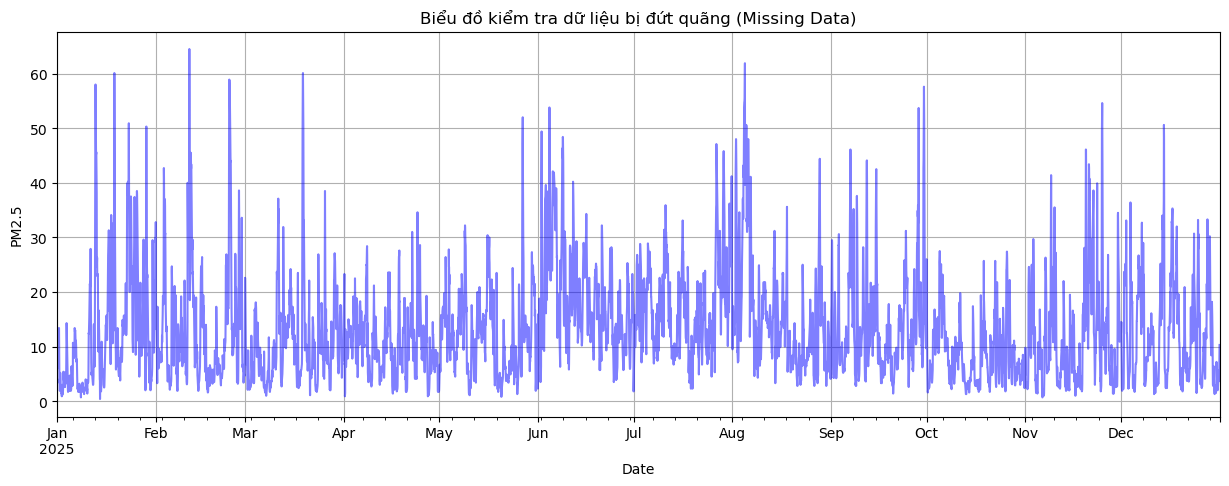


🧹 Sau khi xử lý, số lượng NaN còn lại:
City     0
CO       0
NO2      0
SO2      0
O3       0
PM2.5    0
PM10     0
AQI      0
dtype: int64

✅ Không có dữ liệu trùng lặp.
--------------------------------------------------
🎉 HOÀN THÀNH BƯỚC 1: DỮ LIỆU ĐÃ SẠCH SẼ & LIỀN MẠCH!


C:\Users\nguye\AppData\Local\Temp\ipykernel_15500\3366210793.py:42: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_clean = df.interpolate(method='time')


In [6]:


# Giả sử df là dataframe bạn load từ csv ban đầu
# df = pd.read_csv('Ten_File_Cua_Ban.csv')

# ==============================================================================
# 1.1. CHUẨN HÓA CỘT THỜI GIAN (BẮT BUỘC)
# ==============================================================================
# Chuyển đổi sang định dạng datetime chuẩn của Python
df['Date'] = pd.to_datetime(df['Date'])

# Sắp xếp lại dữ liệu theo thời gian (đề phòng dữ liệu bị lộn xộn)
df = df.sort_values('Date')

# Đặt Date làm Index (Mục lục) để dễ xử lý
df.set_index('Date', inplace=True)

print("✅ Đã chuẩn hóa thời gian và set Index thành công!")

# ==============================================================================
# 1.2. KIỂM TRA DỮ LIỆU BỊ THIẾU (MISSING VALUES)
# ==============================================================================
print("\n🔍 Kiểm tra số lượng ô trống (NaN) trong dữ liệu:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0]) # Chỉ in những cột bị thiếu

# Vẽ biểu đồ xem chỗ nào bị khuyết (Trực quan hóa)
plt.figure(figsize=(15, 5))
# Ví dụ vẽ cột PM2.5, những chỗ đứt đoạn là thiếu dữ liệu
df['PM2.5'].plot(color='blue', alpha=0.5, title='Biểu đồ kiểm tra dữ liệu bị đứt quãng (Missing Data)')
plt.ylabel('PM2.5')
plt.grid(True)
plt.show()

# ==============================================================================
# 1.3. LẤP ĐẦY DỮ LIỆU (IMPUTATION) - QUAN TRỌNG
# ==============================================================================
# Với dữ liệu thời tiết/không khí, KHÔNG ĐƯỢC dùng số 0 để điền (vì không khí không bao giờ bằng 0).
# Cũng KHÔNG NÊN drop (xóa) vì sẽ làm đứt gãy chuỗi thời gian.
# -> Cách tốt nhất: Nội suy tuyến tính (Interpolate) theo thời gian.
# (Ví dụ: 8h là 10, 10h là 20 -> Máy tự tính 9h là 15)

# Lấp đầy các ô trống
df_clean = df.interpolate(method='time')

# Kiểm tra lại lần nữa cho chắc
print("\n🧹 Sau khi xử lý, số lượng NaN còn lại:")
print(df_clean.isnull().sum())

# ==============================================================================
# 1.4. XỬ LÝ DỮ LIỆU TRÙNG LẶP (DUPLICATES)
# ==============================================================================
# Đôi khi cảm biến gửi 2 lần 1 lúc
duplicates = df_clean.index.duplicated().sum()
if duplicates > 0:
    print(f"\n⚠️ Phát hiện {duplicates} mốc thời gian bị trùng! Đang xử lý...")
    # Giữ lại bản ghi đầu tiên, xóa bản ghi trùng
    df_clean = df_clean[~df_clean.index.duplicated(keep='first')]
    print("✅ Đã xóa dữ liệu trùng.")
else:
    print("\n✅ Không có dữ liệu trùng lặp.")

print("-" * 50)
print("🎉 HOÀN THÀNH BƯỚC 1: DỮ LIỆU ĐÃ SẠCH SẼ & LIỀN MẠCH!")

🔧 Đang xử lý Outliers (Phương pháp Capping)...
• PM2.5: Đã ép 34 điểm về ngưỡng [-28.50, 52.00]
• PM10: Đã ép 31 điểm về ngưỡng [-29.60, 54.40]
• NO2: Đã ép 0 điểm về ngưỡng [-62.30, 113.40]
• CO: Đã ép 162 điểm về ngưỡng [-78.00, 587.00]
• SO2: Đã ép 8 điểm về ngưỡng [-9.10, 20.30]
• O3: Đã ép 27 điểm về ngưỡng [-83.00, 197.00]


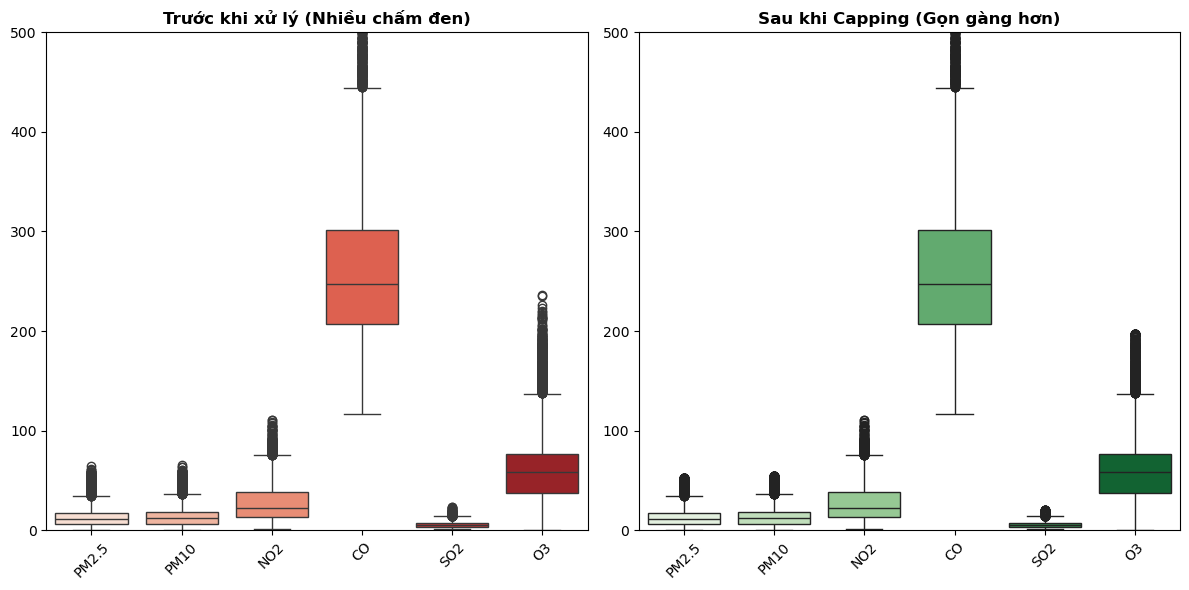

--------------------------------------------------
🎉 HOÀN THÀNH BƯỚC 2: DỮ LIỆU ĐÃ 'NGOAN' HƠN RỒI!


In [9]:


# Danh sách các cột cần xử lý (Các chất ô nhiễm)
cols_to_fix = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3']

# Copy ra một bản mới để giữ bản gốc làm đối chứng
df_final = df_clean.copy()

print("🔧 Đang xử lý Outliers (Phương pháp Capping)...")

for col in cols_to_fix:
    if col in df_final.columns:
        # 1. Tính toán IQR
        Q1 = df_final[col].quantile(0.25)
        Q3 = df_final[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # 2. Xác định giới hạn (Thường dùng 1.5 hoặc 3 lần IQR)
        # Với dữ liệu môi trường biến động mạnh, mình khuyên dùng 3.0 để giữ lại các sự kiện ô nhiễm thật (Extreme events)
        # Nếu dùng 1.5 có thể sẽ làm mất đi các ngày ô nhiễm cao điểm.
        lower_bound = Q1 - 3.0 * IQR
        upper_bound = Q3 + 3.0 * IQR
        
        # 3. Đếm số lượng Outlier trước khi xử lý
        outliers_before = ((df_final[col] < lower_bound) | (df_final[col] > upper_bound)).sum()
        
        # 4. Áp dụng Capping (Kẹp giá trị lại trong khoảng an toàn)
        # Lệnh clip: Nếu nhỏ hơn lower thì thành lower, lớn hơn upper thì thành upper
        df_final[col] = df_final[col].clip(lower=lower_bound, upper=upper_bound)
        
        print(f"• {col}: Đã ép {outliers_before} điểm về ngưỡng [{lower_bound:.2f}, {upper_bound:.2f}]")

# ==============================================================================
# KIỂM TRA HIỆU QUẢ TRƯỚC VÀ SAU (BEFORE vs AFTER)
# ==============================================================================
plt.figure(figsize=(12, 6))

# Vẽ biểu đồ hộp của bản gốc (df_clean) - Màu đỏ
plt.subplot(1, 2, 1)
sns.boxplot(data=df_clean[cols_to_fix], palette='Reds')
plt.title('Trước khi xử lý (Nhiều chấm đen)', fontweight='bold')
plt.ylim(0, 500) # Giới hạn trục Y để dễ nhìn
plt.xticks(rotation=45)

# Vẽ biểu đồ hộp của bản mới (df_final) - Màu xanh
plt.subplot(1, 2, 2)
sns.boxplot(data=df_final[cols_to_fix], palette='Greens')
plt.title('Sau khi Capping (Gọn gàng hơn)', fontweight='bold')
plt.ylim(0, 500)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("-" * 50)
print("🎉 HOÀN THÀNH BƯỚC 2: DỮ LIỆU ĐÃ 'NGOAN' HƠN RỒI!")

🛠️ Đang thực hiện Feature Engineering...


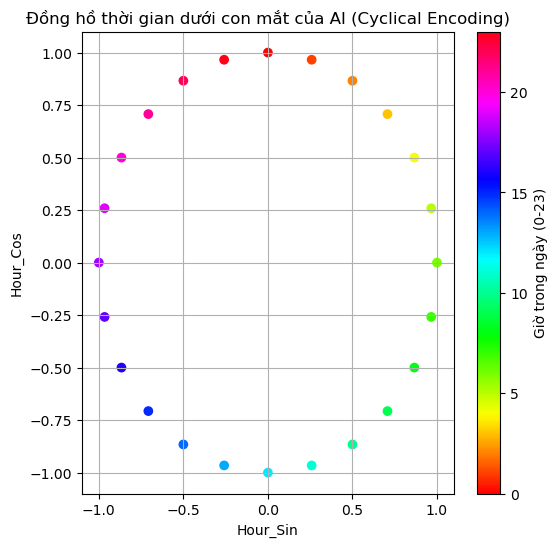

✅ Đã tạo xong các đặc trưng mới!
Dữ liệu hiện tại bao gồm các cột: ['City', 'CO', 'NO2', 'SO2', 'O3', 'PM2.5', 'PM10', 'AQI', 'Hour_Sin', 'Hour_Cos', 'Day_Sin', 'Day_Cos', 'Month_Sin', 'Month_Cos', 'Is_Rush_Hour', 'Is_Weekend']


In [10]:
print("🛠️ Đang thực hiện Feature Engineering...")

# ==============================================================================
# 3.1. TRÍCH XUẤT THÔNG TIN THỜI GIAN CƠ BẢN
# ==============================================================================
# Lấy ra Giờ, Thứ, Tháng từ Index
df_final['Hour'] = df_final.index.hour
df_final['DayOfWeek'] = df_final.index.dayofweek # 0=Thứ 2, 6=Chủ Nhật
df_final['Month'] = df_final.index.month

# ==============================================================================
# 3.2. CYCLICAL ENCODING (KỸ THUẬT QUAN TRỌNG CHO AI)
# ==============================================================================
# Biến đổi giờ thành tọa độ hình tròn (Sin/Cos)
# Giúp AI hiểu 23h rất gần với 0h
df_final['Hour_Sin'] = np.sin(2 * np.pi * df_final['Hour'] / 24)
df_final['Hour_Cos'] = np.cos(2 * np.pi * df_final['Hour'] / 24)

# Biến đổi thứ trong tuần (Chu kỳ 7 ngày)
df_final['Day_Sin'] = np.sin(2 * np.pi * df_final['DayOfWeek'] / 7)
df_final['Day_Cos'] = np.cos(2 * np.pi * df_final['DayOfWeek'] / 7)

# Biến đổi tháng (Chu kỳ 12 tháng)
df_final['Month_Sin'] = np.sin(2 * np.pi * df_final['Month'] / 12)
df_final['Month_Cos'] = np.cos(2 * np.pi * df_final['Month'] / 12)

# ==============================================================================
# 3.3. DOMAIN KNOWLEDGE FEATURES (KIẾN THỨC CHUYÊN GIA)
# ==============================================================================
# Tạo cột "Giờ cao điểm" (Rush Hour)
# Sáng: 7h-9h, Chiều: 16h-19h
def is_rush_hour(h):
    if (7 <= h <= 9) or (16 <= h <= 19):
        return 1 # Có kẹt xe
    return 0     # Không kẹt xe

df_final['Is_Rush_Hour'] = df_final['Hour'].apply(is_rush_hour)

# Tạo cột "Cuối tuần" (Weekend)
# Thứ 7 (5) và CN (6) thường ít xe tải hơn
df_final['Is_Weekend'] = df_final['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# ==============================================================================
# 3.4. MINH HỌA HIỆU QUẢ CỦA CYCLICAL ENCODING
# ==============================================================================
# Vẽ thử 24 giờ trong ngày xem nó có thành hình tròn không?
plt.figure(figsize=(6, 6))
plt.scatter(df_final['Hour_Sin'][:24], df_final['Hour_Cos'][:24], c=range(24), cmap='hsv')
plt.title('Đồng hồ thời gian dưới con mắt của AI (Cyclical Encoding)')
plt.xlabel('Hour_Sin')
plt.ylabel('Hour_Cos')
plt.colorbar(label='Giờ trong ngày (0-23)')
plt.grid(True)
plt.show()

# Xóa bỏ các cột thô không cần thiết nữa (để tránh nhiễu)
# AI chỉ cần Sin/Cos, không cần cột Hour số nguyên nữa
cols_to_drop = ['Hour', 'DayOfWeek', 'Month']
df_final = df_final.drop(columns=cols_to_drop)

print("✅ Đã tạo xong các đặc trưng mới!")
print("Dữ liệu hiện tại bao gồm các cột:", df_final.columns.tolist())

In [12]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import joblib

print("⚖️ Đang thực hiện Scaling & Splitting...")

# ==============================================================================
# 4.1. CHỌN FEATURES (ĐẦU VÀO) & TARGET (ĐÍCH ĐẾN)
# ==============================================================================
# Chọn tất cả các cột chúng ta đã tạo ra
# Lưu ý: Cột đầu tiên nên là cái bạn muốn dự đoán (PM2.5) để dễ xử lý sau này
feature_cols = ['PM2.5', 'NO2', 'CO', 'O3', 'SO2', 
                'Hour_Sin', 'Hour_Cos', 'Day_Sin', 'Day_Cos', 
                'Is_Rush_Hour', 'Is_Weekend']

target_col = 'PM2.5'

# Lấy dữ liệu dạng mảng
data_values = df_final[feature_cols].values

# ==============================================================================
# 4.2. CHIA TRAIN / TEST (CHIA TRƯỚC KHI SCALING)
# ==============================================================================
# Quy tắc: Lấy 80% thời gian đầu để học, 20% thời gian sau để test
train_size = int(len(data_values) * 0.8)

train_data = data_values[:train_size]
test_data = data_values[train_size:]

print(f"• Tổng số mẫu: {len(data_values)}")
print(f"• Tập Train (Học): {len(train_data)} mẫu")
print(f"• Tập Test (Thi): {len(test_data)} mẫu")

# ==============================================================================
# 4.3. SCALING (CHUẨN HÓA VỀ 0-1)
# ==============================================================================
# Lưu ý quan trọng: Chỉ fit scaler trên tập TRAIN, rồi dùng nó transform tập TEST.
# (Để tránh việc Model biết trước thông tin của tương lai - Data Leakage)
scaler = MinMaxScaler(feature_range=(0, 1))

# Học quy luật trên tập Train
scaled_train = scaler.fit_transform(train_data)

# Áp dụng quy luật đó lên tập Test
scaled_test = scaler.transform(test_data)

# LƯU SCALER LẠI NGAY (Để dùng cho Agent sau này)
joblib.dump(scaler, 'final_scaler.pkl')
print("✅ Đã lưu scaler thành công: final_scaler.pkl")

# ==============================================================================
# 4.4. SLIDING WINDOW (CỬA SỔ TRƯỢT) - BIẾN 2D THÀNH 3D
# ==============================================================================
def create_sequences(dataset, look_back=24):
    X, y = [], []
    for i in range(look_back, len(dataset)):
        # Lấy 24 giờ trước đó của TẤT CẢ features làm đầu vào (Input)
        X.append(dataset[i-look_back:i, :]) 
        
        # Lấy PM2.5 của giờ hiện tại làm nhãn (Output)
        # Vì PM2.5 đang nằm ở cột đầu tiên (index 0) trong feature_cols
        y.append(dataset[i, 0]) 
    return np.array(X), np.array(y)

LOOK_BACK = 24 # Nhìn lại 24h

print(f"\n🔄 Đang tạo cửa sổ trượt (Lookback = {LOOK_BACK} giờ)...")
X_train, y_train = create_sequences(scaled_train, LOOK_BACK)
X_test, y_test = create_sequences(scaled_test, LOOK_BACK)

# ==============================================================================
# 4.5. KIỂM TRA HÌNH DẠNG CUỐI CÙNG (SHAPE CHECK)
# ==============================================================================
print("-" * 50)
print("📊 KÍCH THƯỚC DỮ LIỆU SẴN SÀNG CHO LSTM:")
print(f"• X_train shape: {X_train.shape} (Mẫu, 24 giờ, {X_train.shape[2]} đặc trưng)")
print(f"• y_train shape: {y_train.shape}")
print(f"• X_test shape:  {X_test.shape}")
print(f"• y_test shape:  {y_test.shape}")
print("-" * 50)
print("🎉 CHÚC MỪNG! BẠN ĐÃ XONG PHẦN TIỀN XỬ LÝ.")
print("👉 GIỜ CHỈ CẦN COPY ĐOẠN CODE MODEL LSTM LÚC NÃY VÀO LÀ CHẠY RO RO!")
print("-" * 50)
print("💾 ĐANG LƯU DỮ LIỆU ĐÃ XỬ LÝ RA FILE RIÊNG...")

# Tên file lưu trữ
filename = 'processed_data.npz'

# Lệnh thần thánh: Gom hết các biến numpy vào 1 file nén
np.savez(filename, 
         X_train=X_train, 
         y_train=y_train, 
         X_test=X_test, 
         y_test=y_test)

print(f"✅ Đã lưu thành công file: {filename}")
print(f"📂 Vị trí file: {os.path.abspath(filename)}")

# Lưu ý: Cái scaler mình đã lưu bằng joblib ở trên rồi ('final_scaler.pkl')
# Nhớ giữ cả 2 file: .npz (dữ liệu) và .pkl (bộ quy đổi) nhé!
print("-" * 50)

⚖️ Đang thực hiện Scaling & Splitting...
• Tổng số mẫu: 8760
• Tập Train (Học): 7008 mẫu
• Tập Test (Thi): 1752 mẫu
✅ Đã lưu scaler thành công: final_scaler.pkl

🔄 Đang tạo cửa sổ trượt (Lookback = 24 giờ)...
--------------------------------------------------
📊 KÍCH THƯỚC DỮ LIỆU SẴN SÀNG CHO LSTM:
• X_train shape: (6984, 24, 11) (Mẫu, 24 giờ, 11 đặc trưng)
• y_train shape: (6984,)
• X_test shape:  (1728, 24, 11)
• y_test shape:  (1728,)
--------------------------------------------------
🎉 CHÚC MỪNG! BẠN ĐÃ XONG PHẦN TIỀN XỬ LÝ.
👉 GIỜ CHỈ CẦN COPY ĐOẠN CODE MODEL LSTM LÚC NÃY VÀO LÀ CHẠY RO RO!
--------------------------------------------------
💾 ĐANG LƯU DỮ LIỆU ĐÃ XỬ LÝ RA FILE RIÊNG...
✅ Đã lưu thành công file: processed_data.npz
📂 Vị trí file: d:\Project\DAP\Model\processed_data.npz
--------------------------------------------------
